# PCA vs Randomized PCA on CIFAR-10

This notebook follows the structure of the uploaded small-dataset PCA notebook: load and visualize the dataset, run normal PCA and randomized PCA, compare execution time and explained variance, calculate reconstruction error, and visualize reconstructed images.

**Important:** CIFAR-10 contains 50,000 training images of size 32×32×3. Full deterministic PCA can be very expensive, so this notebook uses a configurable subset of the CIFAR-10 training set for the main comparison. Increase `SAMPLE_SIZE` if your machine has enough CPU time and RAM.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import cifar10
from sklearn.decomposition import PCA

np.random.seed(42)

In [4]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Original training shape:", X_train.shape)
print("Original test shape:", X_test.shape)
print("Number of classes:", len(np.unique(y_train)))

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1459s 9us/step
Original training shape: (50000, 32, 32, 3)
Original test shape: (10000, 32, 32, 3)
Number of classes: 10


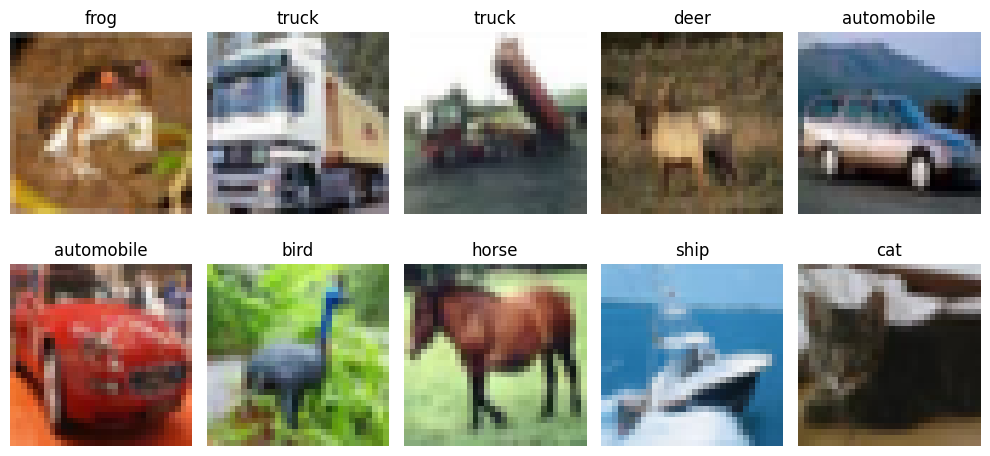

In [6]:
# Visualize sample CIFAR-10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(class_names[int(y_train[i, 0])])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Prepare the data

Each CIFAR-10 image has `32 × 32 × 3 = 3072` pixel values. PCA expects a 2-D matrix, so every image is flattened into one row.

The pixel values are scaled to `[0, 1]`. `SAMPLE_SIZE` controls how many training images are used in the PCA comparison.

In [7]:
SAMPLE_SIZE = 10000   # Increase to 20000 or 50000 if your system can handle it
k = 50                # Number of principal components

X_images = X_train[:SAMPLE_SIZE]
y = y_train[:SAMPLE_SIZE].ravel()

# Flatten each image: (N, 32, 32, 3) -> (N, 3072)
X = X_images.reshape(X_images.shape[0], -1).astype(np.float32) / 255.0

print("PCA input shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Number of components:", k)

PCA input shape: (10000, 3072)
Number of classes: 10
Number of components: 50


In [8]:
import numpy as np

# Save the sampled training images and labels
OUTPUT_FILE = "x_train_10000.npz"

np.savez_compressed(
    OUTPUT_FILE,
    X_train=X_images,
    y_train=y
)

print(f"Saved: {OUTPUT_FILE}")
print(f"X_train shape: {X_images.shape}")
print(f"y_train shape: {y.shape}")

Saved: x_train_10000.npz
X_train shape: (10000, 32, 32, 3)
y_train shape: (10000,)


## Normal PCA

Here `svd_solver="full"` performs the deterministic/full SVD-based PCA.

In [9]:
start = time.perf_counter()

pca_normal = PCA(
    n_components=k,
    svd_solver="full"
)

X_normal = pca_normal.fit_transform(X)

normal_time = time.perf_counter() - start

print("Normal PCA time:", normal_time, "seconds")
print("Output shape:", X_normal.shape)
print("Explained variance:", pca_normal.explained_variance_ratio_.sum())

Normal PCA time: 15.939772004000133 seconds
Output shape: (10000, 50)
Explained variance: 0.84506184


## Randomized PCA

Scikit-learn implements randomized PCA through `PCA(svd_solver="randomized")`. It approximates the leading principal components and is especially useful when the number of requested components is much smaller than the original dimensionality.

In [10]:
start = time.perf_counter()

pca_random = PCA(
    n_components=k,
    svd_solver="randomized",
    random_state=42
)

X_random = pca_random.fit_transform(X)

random_time = time.perf_counter() - start

print("Randomized PCA time:", random_time, "seconds")
print("Output shape:", X_random.shape)
print("Explained variance:", pca_random.explained_variance_ratio_.sum())

Randomized PCA time: 2.363330890999805 seconds
Output shape: (10000, 50)
Explained variance: 0.8450184


## Compare PCA and Randomized PCA

In [11]:
normal_variance = pca_normal.explained_variance_ratio_.sum()
random_variance = pca_random.explained_variance_ratio_.sum()

speedup = normal_time / random_time if random_time > 0 else np.nan

print("========== COMPARISON ==========")
print(f"Dataset size:                 {X.shape[0]} images")
print(f"Features per image:           {X.shape[1]}")
print(f"Number of components:         {k}")
print()
print(f"Normal PCA time:              {normal_time:.6f} seconds")
print(f"Randomized PCA time:          {random_time:.6f} seconds")
print(f"Randomized PCA speed ratio:   {speedup:.2f}x")
print()
print(f"Normal explained variance:    {normal_variance:.6f}")
print(f"Randomized explained variance:{random_variance:.6f}")
print(f"Variance difference:          {abs(normal_variance - random_variance):.6f}")

========== COMPARISON ==========
Dataset size:                 10000 images
Features per image:           3072
Number of components:         50

Normal PCA time:              15.939772 seconds
Randomized PCA time:          2.363331 seconds
Randomized PCA speed ratio:   6.74x

Normal explained variance:    0.845062
Randomized explained variance:0.845018
Variance difference:          0.000043


## Reconstruction error

The transformed data is projected back into the original 3072-dimensional pixel space. Lower MSE means the reconstruction is closer to the original image.

In [12]:
X_normal_reconstructed = pca_normal.inverse_transform(X_normal)
X_random_reconstructed = pca_random.inverse_transform(X_random)

normal_error = np.mean((X - X_normal_reconstructed) ** 2)
random_error = np.mean((X - X_random_reconstructed) ** 2)

print("Normal PCA reconstruction error:", normal_error)
print("Randomized PCA reconstruction error:", random_error)

Normal PCA reconstruction error: 0.00965953
Randomized PCA reconstruction error: 0.0096623255


## Visual comparison

The reconstructed rows are reshaped back to `32 × 32 × 3` images.

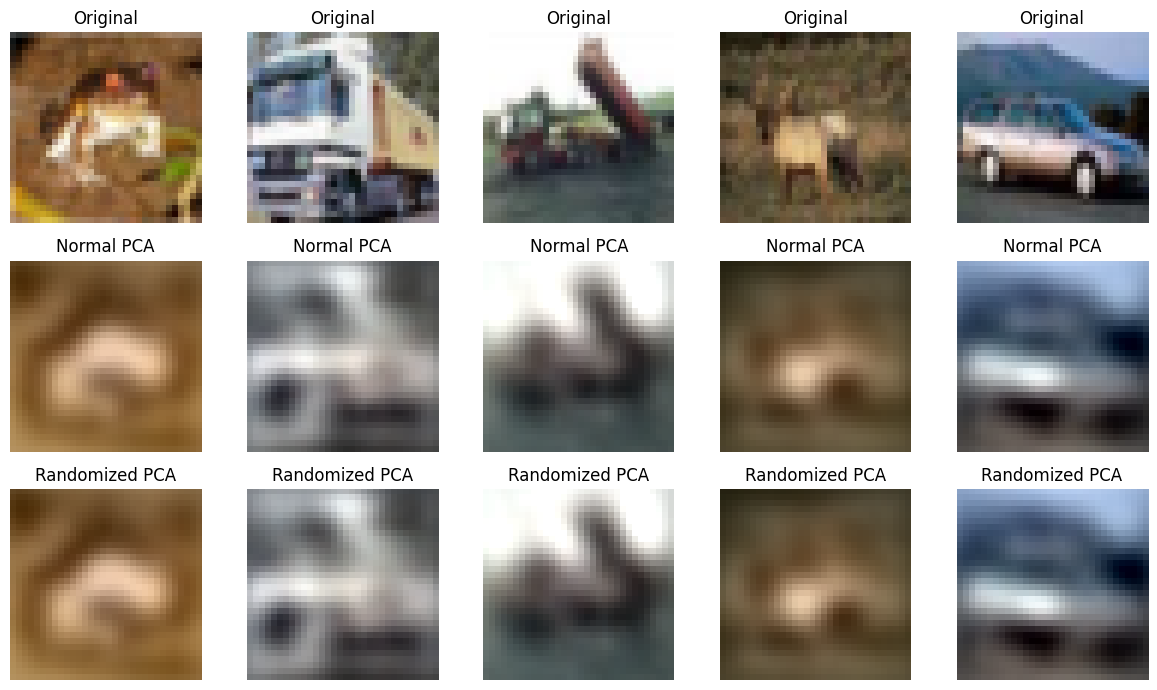

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7))

for i in range(5):
    # Original
    axes[0, i].imshow(X_images[i])
    axes[0, i].set_title("Original")

    # Normal PCA
    normal_img = np.clip(
        X_normal_reconstructed[i].reshape(32, 32, 3),
        0, 1
    )
    axes[1, i].imshow(normal_img)
    axes[1, i].set_title("Normal PCA")

    # Randomized PCA
    random_img = np.clip(
        X_random_reconstructed[i].reshape(32, 32, 3),
        0, 1
    )
    axes[2, i].imshow(random_img)
    axes[2, i].set_title("Randomized PCA")

    for j in range(3):
        axes[j, i].axis("off")

plt.tight_layout()
plt.show()

## Explained variance by component

This plot compares how much variance each component captures for the two methods.

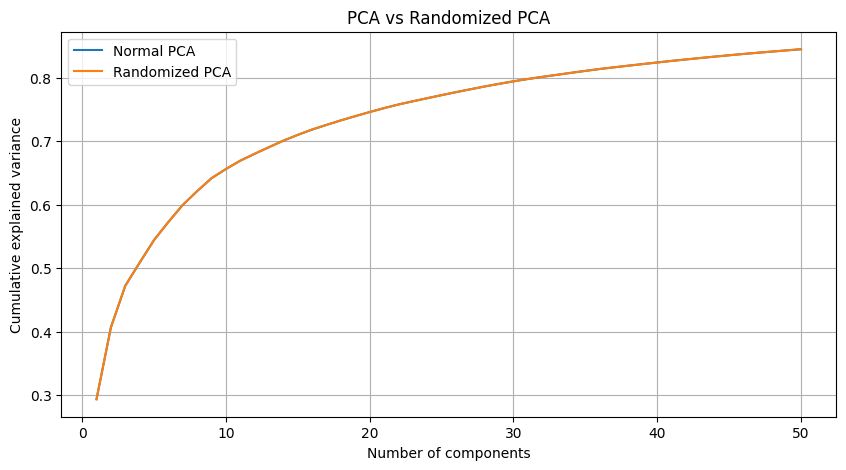

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, k + 1),
    np.cumsum(pca_normal.explained_variance_ratio_),
    label="Normal PCA"
)

plt.plot(
    range(1, k + 1),
    np.cumsum(pca_random.explained_variance_ratio_),
    label="Randomized PCA"
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA vs Randomized PCA")
plt.legend()
plt.grid(True)
plt.show()

# Comparision For differnet Sample sizes

In [18]:
import numpy as np
import pandas as pd
import time
from sklearn.decomposition import PCA

# Sample sizes to compare
SAMPLE_SIZES = [1000, 10000, 50000]

# Number of principal components
k = 50

results = []

for SAMPLE_SIZE in SAMPLE_SIZES:

    print("\n" + "=" * 60)
    print(f"Running PCA with {SAMPLE_SIZE} samples")
    print("=" * 60)

    # --------------------------------------------------
    # Prepare data
    # --------------------------------------------------
    X_images = X_train[:SAMPLE_SIZE]
    y = y_train[:SAMPLE_SIZE].ravel()

    # Flatten and normalize
    X = X_images.reshape(X_images.shape[0], -1).astype(np.float32) / 255.0

    print("Data shape:", X.shape)

    # --------------------------------------------------
    # Normal PCA
    # --------------------------------------------------
    start_time = time.time()
    start = time.perf_counter()

    pca_normal = PCA(
        n_components=k,
        svd_solver="full"
    )

    X_normal = pca_normal.fit_transform(X)

    normal_time = time.perf_counter() - start


    normal_variance = pca_normal.explained_variance_ratio_.sum()

    # --------------------------------------------------
    # Randomized PCA
    # --------------------------------------------------
    start_time = time.time()

    pca_random = PCA(
        n_components=k,
        svd_solver="randomized",
        random_state=42
    )

    X_random = pca_random.fit_transform(X)

    random_time = time.time() - start_time

    random_variance = pca_random.explained_variance_ratio_.sum()

    # --------------------------------------------------
    # Comparison
    # --------------------------------------------------
    variance_difference = abs(
        normal_variance - random_variance
    )

    speedup = normal_time / random_time

    results.append({
        "Sample Size": SAMPLE_SIZE,
        "Normal PCA Time (s)": normal_time,
        "Randomized PCA Time (s)": random_time,
        "Speedup (x)": speedup,
        "Normal Explained Variance": normal_variance,
        "Randomized Explained Variance": random_variance,
        "Variance Difference": variance_difference
    })

    print(f"Normal PCA time:               {normal_time:.4f} s")
    print(f"Randomized PCA time:           {random_time:.4f} s")
    print(f"Speedup:                       {speedup:.2f}x")
    print(f"Normal explained variance:     {normal_variance:.6f}")
    print(f"Randomized explained variance: {random_variance:.6f}")
    print(f"Variance difference:            {variance_difference:.6f}")


# ------------------------------------------------------
# Create comparison table
# ------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n========== FINAL COMPARISON ==========")
display(results_df)


Running PCA with 1000 samples
Data shape: (1000, 3072)
Normal PCA time:               0.7098 s
Randomized PCA time:           0.7972 s
Speedup:                       0.89x
Normal explained variance:     0.849829
Randomized explained variance: 0.849751
Variance difference:            0.000078

Running PCA with 10000 samples
Data shape: (10000, 3072)
Normal PCA time:               19.8747 s
Randomized PCA time:           2.3314 s
Speedup:                       8.52x
Normal explained variance:     0.845062
Randomized explained variance: 0.845018
Variance difference:            0.000043

Running PCA with 50000 samples
Data shape: (50000, 3072)
Normal PCA time:               58.1000 s
Randomized PCA time:           7.1298 s
Speedup:                       8.15x
Normal explained variance:     0.843022
Randomized explained variance: 0.842984
Variance difference:            0.000038


========== FINAL COMPARISON ==========


,Sample Size,Normal PCA Time (s),Randomized PCA Time (s),Speedup (x),Normal Explained Variance,Randomized Explained Variance,Variance Difference
0,1000,0.709801,0.797222,0.890344,0.849829,0.849751,0.000078
1,10000,19.874719,2.331359,8.524949,0.845062,0.845018,0.000043
2,50000,58.100042,7.129802,8.148900,0.843022,0.842984,0.000038


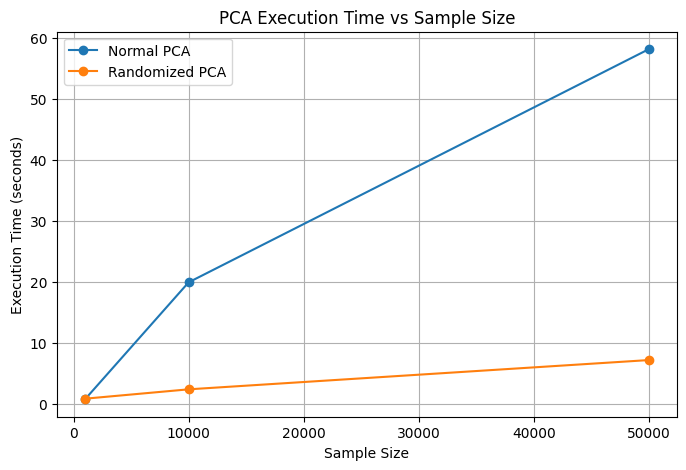

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Sample Size"],
    results_df["Normal PCA Time (s)"],
    marker="o",
    label="Normal PCA"
)

plt.plot(
    results_df["Sample Size"],
    results_df["Randomized PCA Time (s)"],
    marker="o",
    label="Randomized PCA"
)

plt.xlabel("Sample Size")
plt.ylabel("Execution Time (seconds)")
plt.title("PCA Execution Time vs Sample Size")
plt.legend()
plt.grid(True)

plt.show()

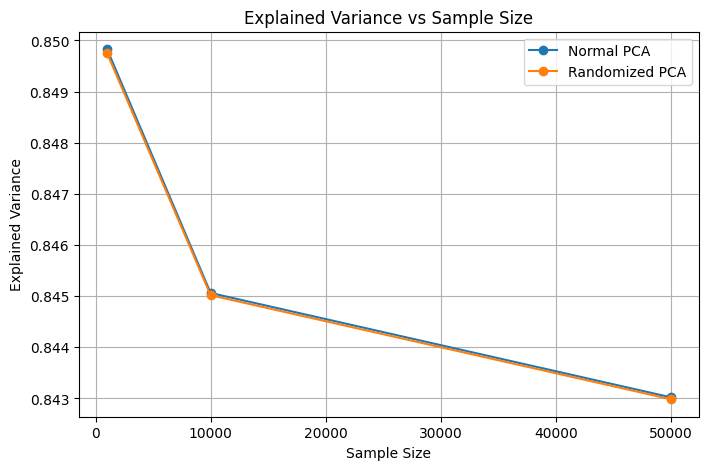

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Sample Size"],
    results_df["Normal Explained Variance"],
    marker="o",
    label="Normal PCA"
)

plt.plot(
    results_df["Sample Size"],
    results_df["Randomized Explained Variance"],
    marker="o",
    label="Randomized PCA"
)

plt.xlabel("Sample Size")
plt.ylabel("Explained Variance")
plt.title("Explained Variance vs Sample Size")
plt.legend()
plt.grid(True)

plt.show()

## Final summary

- **Normal PCA** computes the principal components more exactly but can become expensive as the dataset grows.
- **Randomized PCA** approximates the leading components and can be substantially faster for large datasets when `k` is relatively small.
- The two methods should produce very similar explained variance and reconstruction quality when the randomized approximation is sufficiently accurate.
- For a stronger scalability experiment, repeat the comparison with `SAMPLE_SIZE = 5000`, `10000`, `20000`, and `50000`, and record the execution time for each method.